In [1]:
import pandas as pd
import librosa 
from pathlib import Path
import numpy as np 
import soundfile as sf
from IPython.display import Audio
import scipy.signal as sig
from tqdm import tqdm 


## Create windowing function

Need to fade onsets and offsets of cue and mixture to avoid popping

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
ramp_dur_smp =  np.floor(10 * 20_000 / 1000).astype('int')
win = sig.hann((2 * ramp_dur_smp) + 2)[1:-1]

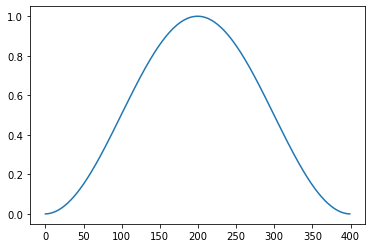

In [4]:
plt.plot(win); # eg of window - we'll use each half for the front and back of a signal 

In [5]:
## Define windowing function - will apply a cosine ramp to the start and end of a signal

def ramp_hann(x, ramp_dur_ms, samplerate=20_000):
    stim_dur_smp = x.shape[0] # N taps of x
    ramp_dur_smp =  np.floor(ramp_dur_ms * samplerate / 1000).astype('int')
    assert stim_dur_smp > (2*ramp_dur_smp), 'Ramps cannot be longer than the stimulus duration'
    
    # calc window
    # https://stackoverflow.com/questions/56485663/hanning-window-values-doesnt-match-in-python-and-matlab
    win = sig.hann((2 * ramp_dur_smp) + 2)[1:-1]
    
    # Beginning of windowed stimulus
    start_win = win[ : ramp_dur_smp ] * x[ : ramp_dur_smp]
    
    # Middle part (steady state)
    steady_win = x[ramp_dur_smp : stim_dur_smp-ramp_dur_smp]
    
    # Final part of windowed stimulus
    end_win = win[ramp_dur_smp : ramp_dur_smp*2] * x[stim_dur_smp-ramp_dur_smp:stim_dur_smp]

    return np.hstack([start_win, steady_win, end_win])

def rms_normalize(wav, new_rms=0.07, axis=0): 
    wav = wav - wav.mean(axis=axis)
    rms_wav = np.sqrt(np.mean(np.power(wav, 2), axis=axis))
    wav = wav * new_rms / rms_wav
    return wav


# Generate stim for each dataset 

To make stimuli, combine cue, isi, and mixture for each trial into a wav form, and save it to our server.  

Naming convention:
`/full/path/<set_ix>_<ix_in_pandas>_<noise_cond>_<snr>_<word_int>_<speaker_sex>.wav`

This will let us map the audio back to the rows in its parent pandas dataframe

#### Generate trial audio data for each attentive listening task dataset 

In [6]:
# Get path to pandas dataframes 

In [7]:
df_paths = list(Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes/').glob('*.pdpkl'))

In [8]:
## Define default params

sampling_rate = 20_000 # 20kHz
sig_ramp_dur = 10 # in ms 
isi_in_frames = int(0.25 * sampling_rate) # 250ms at 20kHz

isi_array = np.zeros(isi_in_frames)

out_dir = Path('/mindhive/mcdermott/www/mturk_stimuli/imgriff/timit_attentive_listening_task/') 

In [9]:
task_df = pd.read_pickle(df_paths[0])


In [9]:
df_paths

[PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_00.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_01.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_02.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_03.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_04.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_05.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_06.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_07.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_08.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_dataset_09.pdpkl'),
 PosixPath('/om2/user/imgriff/datasets/t

In [10]:
task_df.iloc[10]

_original_timit_index                                                              5364
word                                                                              power
source                                                            train-dr6-fbch0-sx416
speaker                                                                           fbch0
sr                                                                                20000
signal_length                                                                     40000
speaker_sex                                                                           f
sentence_type                                                                        sx
sentence_id                                                                         416
dialect_region                                                                      dr6
signal                                [0.00034761254498702796, 0.0003728516746046758...
word_int                        

In [11]:
task_df['distractor_conditions'][411] == 'catch trial'

True

In [25]:
eg = task_df[task_df.snrs == 3].iloc[1]

In [26]:
Audio(eg.mixture_signal, rate=20000, normalize=False)

In [27]:
Audio(eg.cue_signal, rate=20000, normalize=False)

In [29]:
## Egs for talk

cue = ramp_hann(eg.cue_signal, 20)
mixture = ramp_hann(eg.mixture_signal, 20)

In [30]:
Audio(mixture, rate=20000, normalize=False)

In [32]:
mix_out_name = Path('/om2/user/imgriff/demos/EST_2022/')
if not mix_out_name.exists():
        mix_out_name.mkdir(parents=True, exist_ok=True)
        
f_name = mix_out_name / 'timit_mix_3dB_1_distractor.wav'

sf.write(f_name, mixture, 20_000, subtype='PCM_16') 

In [33]:
f_name = mix_out_name / 'timit_cue.wav'

sf.write(f_name, cue, 20_000, subtype='PCM_16') 

In [12]:
np.where(task_df['cue_snr'] == task_df['cue_snr'].max())

(array([  1,  13,  20,  30,  31,  32,  33,  35,  36,  40,  42,  48,  53,
         54,  58,  62,  64,  67,  69,  72,  73,  74,  76,  81,  83,  88,
         93, 105, 109, 124, 128, 134, 136, 137, 138, 139, 147, 150, 153,
        155, 158, 159, 162, 168, 169, 171, 175, 189, 195, 200, 216, 223,
        225, 226, 233, 236, 243, 246, 248, 249, 250, 254, 258, 261, 262,
        264, 268, 269, 271, 275, 278, 279, 283, 286, 296, 297, 304, 313,
        314, 315, 318, 319, 320, 321, 323, 324, 327, 347, 349, 350, 359,
        362, 363, 371, 373, 377, 378, 381, 383, 398]),)

In [13]:
task_df.columns

Index(['_original_timit_index', 'word', 'source', 'speaker', 'sr',
       'signal_length', 'speaker_sex', 'sentence_type', 'sentence_id',
       'dialect_region', 'signal', 'word_int', 'cue_signal', 'cue_word',
       '_original_cue_timit_index', 'cue_speaker', 'mixture_signal',
       'distractor_signal', '_original_distractor_timit_indices',
       'distractor_words', 'distractor_speakers', 'distractor_conditions',
       'distractor_sex', 'snrs', 'cue_snr'],
      dtype='object')

In [14]:
task_df.iloc[267]

_original_timit_index                                                              6607
word                                                                              eight
source                                                            train-dr7-mgsl0-sx264
speaker                                                                           mgsl0
sr                                                                                20000
signal_length                                                                     40000
speaker_sex                                                                           m
sentence_type                                                                        sx
sentence_id                                                                         264
dialect_region                                                                      dr7
signal                                [0.00020120674909826725, 8.218275071048526e-05...
word_int                        

In [15]:
cue, mixture = task_df.loc[267,['cue_signal', 'mixture_signal']]

In [16]:
cue = ramp_hann(cue, sig_ramp_dur)
mixture = ramp_hann(mixture, sig_ramp_dur)
# combine as trial audio
trial_wav = rms_normalize(np.hstack([cue, isi_array, mixture]))

In [17]:
Audio(trial_wav, rate=sampling_rate, normalize=False)

In [18]:
cue, mixture = task_df.loc[403,['cue_signal', 'mixture_signal']]
cue = ramp_hann(cue, sig_ramp_dur)
mixture = ramp_hann(mixture, sig_ramp_dur)
# combine as trial audio
catch_trial_wav = np.hstack([cue, isi_array, mixture])


In [19]:
Audio(catch_trial_wav, rate=sampling_rate, normalize=False)

# Save files to condition directories 

one directory for each distractor x snr condition
e.g.: `/timit_attentive_listening_task/one_distractor_-5dB_SNR`  or `/timit_attentive_listening_task/ssn_distractor_10dB_SNR`

file names inside directory have mapping back to pandas df and relevant labeling for analysis:
`<set_ix>_<ix_in_pandas>_<noise_cond>_<snr>_<word_int>_<speaker_sex>.wav`

In [20]:
distractor_map = {1:'one',
                 2:'two',
                 4:'four'}

In [26]:
dataset

,_original_timit_index,word,source,speaker,sr,signal_length,speaker_sex,sentence_type,sentence_id,dialect_region,...,cue_speaker,mixture_signal,distractor_signal,_original_distractor_timit_indices,distractor_words,distractor_speakers,distractor_conditions,distractor_sex,snrs,cue_snr
0,612,example,train-dr2-faem0-si1392,faem0,20000,40000,f,si,1392,dr2,...,faem0,"[0.021357156322350076, 0.025801433713278345, 0...","[0.02598474168034081, 0.031491083300063366, 0....","[8857, 2405, 7933, 6424]","[ended, particularly, served, famous]","[mdrm0, mdhs0, mmdb1, mded0]",4,mmmm,-3,-3.0
1,627,their,train-dr2-fajw0-si1263,fajw0,20000,40000,f,si,1263,dr2,...,fajw0,"[0.006548380849468521, -0.012040014591002571, ...","[0.0011939308156294099, -0.0010738329924349312...",ssn,ssn,ssn,ssn,ssn,3,3.0
2,3134,majority,train-dr4-falr0-si1325,falr0,20000,40000,f,si,1325,dr4,...,falr0,"[0.0038653575644131857, 0.003787759285211831, ...","[-0.002291699611663041, -0.0022297216028135344...",[6610],[appointed],[mgsl0],1,m,-6,-6.0
3,5345,child,train-dr6-fapb0-sx343,fapb0,20000,40000,f,sx,343,dr6,...,fapb0,"[8.660285461392886e-06, 3.727941454883223e-05,...","[-0.0001617722662905093, 7.303222581187876e-05...",[1176],[group],[mdss0],1,m,-6,-6.0
4,9127,after,test-dr5-fawf0-sx190,fawf0,20000,40000,f,sx,190,dr5,...,fawf0,"[-0.003458555431358873, 0.007210018764692847, ...","[-0.005181012093857272, 0.010682500949803667, ...","[1732, 3999, 6913, 7922]","[their, judge, began, black]","[mrlj0, mpeb0, mrmg0, mjar0]",4,mmmm,-6,-6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407,10219,without,test-dr8-mjln0-sx279,mjln0,20000,40000,m,sx,279,dr8,...,mjln0,"[-0.01080892001191579, -0.014591917796042589, ...",catch trial,catch trial,catch trial,catch trial,catch trial,NaN,catch trial,NaN
408,5049,passed,train-dr5-mram0-si1905,mram0,20000,40000,m,si,1905,dr5,...,mram0,"[-0.00920238488938592, -0.010037016539419397, ...",catch trial,catch trial,catch trial,catch trial,catch trial,NaN,catch trial,NaN
409,5161,strong,train-dr5-msas0-si1376,msas0,20000,40000,m,si,1376,dr5,...,msas0,"[0.0005241776821884307, 0.0009178446325824346,...",catch trial,catch trial,catch trial,catch trial,catch trial,NaN,catch trial,NaN
410,5205,famous,train-dr5-msem1-sx90,msem1,20000,40000,m,sx,90,dr5,...,msem1,"[0.0042282612724796305, 0.0026893794372883613,...",catch trial,catch trial,catch trial,catch trial,catch trial,NaN,catch trial,NaN


In [23]:
# for df_path in tqdm(df_paths):
# #     if 'training' in df_path.as_posix():
# #         continue 
#     dataset = pd.read_pickle(df_path)
#     if ((dataset['word'] == dataset['cue_word'])& dataset['distractor_condition']!='catch trail').any():
#         print(df_path)
#     if (np.stack(dataset['signal']) == np.stack(dataset['cue_signal'])).any():
#         print(df_path)

In [28]:
for df_ix, df_path in tqdm(enumerate(df_paths)):
    if 'training' in df_path.as_posix():
        continue 
    dataset = pd.read_pickle(df_path)
    # loop over trials
    for trial in range(len(dataset)):
        # get cue and mixture signal
        cue, mixture = dataset.loc[trial, ['cue_signal', 'mixture_signal']]
        noise_cond = dataset['distractor_conditions'][trial]
        snr = dataset['snrs'][trial]
        word_int = dataset['word_int'][trial]
        speaker_sex = dataset['speaker_sex'][trial]
        # fade cue and mixture
        cue = ramp_hann(cue, sig_ramp_dur)
        mixture = ramp_hann(mixture, sig_ramp_dur)
        # combine as trial audio
        trial_wav = np.hstack([cue, isi_array, mixture])
        # get dir name for stimulus
        if noise_cond == 'catch trial':
            dir_name = 'catch_trials'
            stim_name = f"set_{df_ix:02d}_stim_{trial:03d}_word_{word_int}_speaker_{speaker_sex}.wav"
        else:
            noise_name = distractor_map[int(noise_cond)] if noise_cond != 'ssn' else 'ssn'
            dir_name = f"{noise_name}_distractor_{snr}dB_snr"
            stim_name = f"set_{df_ix:02d}_stim_{trial:03d}_cond_{noise_cond}_snr_{snr}_word_{word_int}_speaker_{speaker_sex}.wav"
        
        dataset_out_path = out_dir / dir_name
        if not dataset_out_path.exists():
            dataset_out_path.mkdir(parents=True, exist_ok=True)
        out_name = dataset_out_path / stim_name
        # write file 
        sf.write(out_name.as_posix(), trial_wav, sampling_rate, subtype='PCM_16') 

    

11it [00:14,  1.28s/it]


In [29]:
noise_cond

'catch trial'

### Save training stimulti 

In [11]:
training_stim_file = '/om2/user/imgriff/datasets/timit/attn_task_dataframes/attn_task_training_excerpts.pdpkl'

train_set = pd.read_pickle(training_stim_file)


In [14]:
train_set.head()

,_original_timit_index,word,source,speaker,sr,signal_length,speaker_sex,sentence_type,sentence_id,dialect_region,signal,word_int,cue_signal,cue_word,_original_cue_timit_index,cue_speaker
0,8572,needed,test-dr4-fcft0-sx368,fcft0,20000,40000,f,sx,368,dr4,"[0.00011094248105231591, 0.0001679826731135585...",450,"[0.04792072963271731, 0.03598703685527364, 0.0...",oily,8563,fcft0
1,7679,expected,test-dr2-fcmr0-sx205,fcmr0,20000,40000,f,sx,205,dr2,"[-0.0005790408008140293, -0.001001866541698006...",253,"[-0.036377900099321694, -0.042766877007107414,...",up,7675,fcmr0
2,5935,situation,train-dr7-fcrz0-si2053,fcrz0,20000,40000,f,si,2053,dr7,"[0.008558774063336952, 0.0020222148789102706, ...",654,"[0.00358540716518209, 0.00266543354898426, 0.0...",an,5931,fcrz0
3,4305,music,train-dr5-fdmy0-sx297,fdmy0,20000,40000,f,sx,297,dr5,"[-0.045337446458735754, -0.04936817491795092, ...",441,"[-0.0003085411541804638, -6.263832622340351e-0...",pair,4299,fdmy0
4,66,light,train-dr1-fetb0-sx248,fetb0,20000,40000,f,sx,248,dr1,"[6.136765817866252e-05, 2.8603644386108485e-05...",393,"[0.00024669986441104385, 0.0003374186407384911...",carry,57,fetb0


In [15]:
train_set.columns

Index(['_original_timit_index', 'word', 'source', 'speaker', 'sr',
       'signal_length', 'speaker_sex', 'sentence_type', 'sentence_id',
       'dialect_region', 'signal', 'word_int', 'cue_signal', 'cue_word',
       '_original_cue_timit_index', 'cue_speaker'],
      dtype='object')

In [18]:
dir_name = "feedback_trials_train_data"

for trial in range(len(train_set)):
    # get cue and mixture signal
    cue, signal = train_set.loc[trial, ['cue_signal', 'signal']]
    word_int = train_set['word_int'][trial]
    speaker_sex = train_set['speaker_sex'][trial]
    # fade cue and mixture
    cue = ramp_hann(cue, sig_ramp_dur)
    signal = ramp_hann(signal, sig_ramp_dur)
    # combine as trial audio
    trial_wav = np.hstack([cue, isi_array, signal])

    dataset_out_path = out_dir / dir_name
    if not dataset_out_path.exists():
        dataset_out_path.mkdir(parents=True, exist_ok=True)
    # <set_ix>_<ix_in_pandas>_<noise_cond>_<snr>_<word_int>_<speaker_sex>.wav
    stim_name = f"train_set_stim_{trial:02d}_word_{word_int}_speaker_{speaker_sex}.wav"
    out_name = dataset_out_path / stim_name
    # write file 
    sf.write(out_name.as_posix(), trial_wav, sampling_rate, subtype='PCM_16') 



In [ ]:
wav, fs = sf.read(out_name)

In [ ]:
Audio(out_name)